### Сжатие файлов с помощью модуля zipfile

Python-программы могут как создавать, так и открывать (или распаковывать) ZIP-файлы с помощью функции из модуля zipfile. 

https://docs.python.org/3.6/library/zipfile.html

https://docs-python.ru/standart-library/modul-zipfile-python/obekt-zipfile-modulja-zipfile/

Предположим, у вас имеется ZIP-файл my.zip

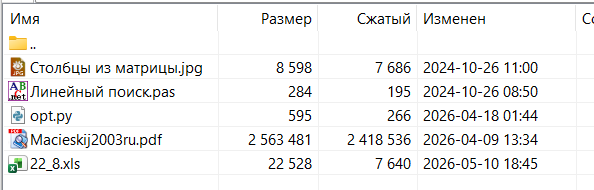

#### Чтение zip-файлов

Чтобы прочитать содержимое ZIP-файла, прежде всего необходимо создать объект ZipFile.

Объекты `ZipFile` концептуально напоминают объекты `File`, возвращаемые функцией `open()`: они представляют собой значения, посредством которых программа взаимодействует с файлами. 

Для создания объекта `ZipFile` следует вызвать функцию `zipfile.ZipFile()`, передав ей строку с именем .zip-файла. .

Обратите внимание на то, что `zipfile` – это имя модуля Python, a `ZipFile()` — имя функции

Объект `ZipFile` имеет метод `namelist()`, который возвращает список строк для всех файлов и папок, содержащихся в ZIP-файле. 

In [ ]:
import zipfile

myfile = zipfile.ZipFile('my.zip')
lst = myfile.namelist()
print(lst)
myfile.close()

['22_8.xls', 'Macieskij2003ru.pdf', 'opt.py', 'Линейный поиск.pas', 'Столбцы из матрицы.jpg']


Метод `ZipFile.close()` закрывает файл архива. 

Необходимо вызвать этот метод перед выходом из программы, иначе не вся информация будет записана или используйте менеджер контекста.

Эти строки можно передать методу `getinfo()` объекта `ZipFile`, который возвратит объект `ZipInfo`, содержащий информацию о данном файле. 

In [6]:
file_info = myfile.getinfo(lst[0])
print(file_info)

<ZipInfo filename='22_8.xls' compress_type=deflate filemode='-rw-rw-rw-' file_size=22528 compress_size=7640>


Объекты `ZipInfo` имеют собственные атрибуты, такие как `file_size` и `compress_size`, которые содержат соответственно целочисленные значения размера исходного и сжатого файлов, выраженные в байтах. 


In [8]:
print(file_info.file_size)
print(file_info.compress_size)

22528
7640


В то время как объект `ZipFile` представляет весь архивный файл, объект `ZipInfo` хранит полезную информацию относительно отдельного файла в сжатом архиве.

In [12]:
print(file_info.compress_type)

8


Метод `infolist()` возвращает информацию о файлах в архиве с виде списка, где каждый отдельный файл представлен объектом `ZipInfo`:

In [14]:
from zipfile import ZipFile
 
with ZipFile('my.zip', 'r') as myzip:
    print(myzip.infolist())

[<ZipInfo filename='22_8.xls' compress_type=deflate filemode='-rw-rw-rw-' file_size=22528 compress_size=7640>, <ZipInfo filename='Macieskij2003ru.pdf' compress_type=deflate filemode='-rw-rw-rw-' file_size=2563481 compress_size=2418536>, <ZipInfo filename='opt.py' compress_type=deflate filemode='-rw-rw-rw-' file_size=595 compress_size=266>, <ZipInfo filename='Линейный поиск.pas' compress_type=deflate filemode='-rw-rw-rw-' file_size=284 compress_size=195>, <ZipInfo filename='Столбцы из матрицы.jpg' compress_type=deflate filemode='-rw-rw-rw-' file_size=8598 compress_size=7686>]


Класс `ZipInfo` предоставляет ряд атрибутов для хранения информации о файле. 

Основные из них:
- filename: название файла
- date_time: дата и время последнего изменения файла в виде кортежа в формате (год, месяц, день, час, минута, секунда)
- compress_type: тип сжатия
- compress_size: размер после сжатия
- file_size: оригинальный размер файла до сжатия

Получим эти данные по каждому отдельному файлу в архиве:

In [16]:
from zipfile import ZipFile
 
with ZipFile('my.zip', 'r') as myzip:
    for item in myzip.infolist():
        print(f"Имя: {item.filename} Дата: {item.date_time} Размер: {item.file_size}")

Имя: 22_8.xls Дата: (2026, 5, 10, 18, 45, 46) Размер: 22528
Имя: Macieskij2003ru.pdf Дата: (2026, 4, 9, 13, 34, 56) Размер: 2563481
Имя: opt.py Дата: (2026, 4, 18, 1, 44, 36) Размер: 595
Имя: Линейный поиск.pas Дата: (2024, 10, 26, 8, 50, 56) Размер: 284
Имя: Столбцы из матрицы.jpg Дата: (2024, 10, 26, 11, 0, 48) Размер: 8598


In [25]:
from zipfile import ZipFile
 
with ZipFile('my_with_dir.zip', 'r') as myzip:
    for elem in myzip.infolist():
        print(f"Файл: {elem.filename}")

Файл: 22_8.xls
Файл: Macieskij2003ru.pdf
Файл: opt.py
Файл: Линейный поиск.pas
Файл: Столбцы из матрицы.jpg
Файл: 02_Python/bonus-1-c177edc7-6e8e-4e53-8f5d-098bd95cc4de-e6e1e463-001c-49ff-adc4-ef6500457b1e.csv
Файл: 02_Python/ha1.ipynb
Файл: 02_Python/wage-1-ee13a6b1-605e-44fe-83a6-85d3d7a0b3ae-2873619c-9efe-44e2-932a-f6fed7be056b.csv


In [23]:
from zipfile import ZipFile

with ZipFile('my_with_dir.zip', 'r') as myzip:
    dirs = set()
    for elem in myzip.infolist():
        if elem.is_dir():
            print(f" Папка (явная): {elem.filename}")
        else:
            # Извлекаем путь к директории из полного пути файла
            # Используем split по '/', так как в ZIP всегда прямой слэш
            path_parts = elem.filename.split('/')
            if len(path_parts) > 1:
                # Берём все части пути, кроме имени файла
                dir_path = '/'.join(path_parts[:-1])
                dirs.add(dir_path)
                
    print("Папки, восстановленные из путей файлов:")
    for d in sorted(dirs):
        print(f"Папка: {d}")

Папки, восстановленные из путей файлов:
Папка: 02_Python


In [2]:
from zipfile import ZipFile
 
with ZipFile('my_with_dir.zip', 'r') as myzip:
    try:
        hello_file = myzip.getinfo('opt.py')
        print(hello_file.file_size)
    except KeyError:
        print("Файл отсутствует")

595


#### Извлечение файлов из ZIP-архива

Метод `extractall()` объектов `ZipFile` извлекает все файлы и папки из ZIP-файла в текущий рабочий каталог.

`extractall(path=None, members=None, pwd=None)`

Первый параметр метода устанавливает каталог для извлечения архива (по умолчанию извлечение идет в текущий каталог). Если переданная методу extractall()  папка  не  существует,  то  она  будет 
создана. 


Параметр members представляет список строк - список названий файлов, которые надо извлечь из архива. 

Параметр - pwd представляет пароль, в случае если архив закрыт паролем.

In [1]:
import zipfile

myzip = zipfile.ZipFile('my_with_dir.zip')
myzip.extractall('my_zip')
myzip.close()

In [5]:
from zipfile import ZipFile
 
with ZipFile('my_with_dir.zip') as myzip:
    myzip.extractall('my_zip')

Метод `extract()` объектов `ZipFile` извлекает одиночный файл из ZIP-файла. 

Передаваемая методу `extract()` строка должна соответствовать одной из строк в списке, возвращаемом методом `namelist()`.

In [7]:
from zipfile import ZipFile
 
with ZipFile('my_with_dir.zip') as myzip:
    k = myzip.extract('opt.py')
    print(k)

c:\YandexDisk-it-math.ru\Subjects\ВУМИП\!_Lections\Работа с путями\opt.py


Метод `extract()` возвращает абсолютный путь, по которому был распакован данный файл.

Методу `extract()` также можно передавать необязательный второй параметр, обеспечивающий возможность извлечения файлов в папку, не являющуюся текущим рабочим каталогом. Если заданная вторым параметром папка не существует, Python создаст ее. 


In [8]:
from zipfile import ZipFile
 
with ZipFile('my_with_dir.zip') as myzip:
    k = myzip.extract('opt.py','New')
    print(k)

New\opt.py


#### Создание ZIP-файлов и добавление в них новых файлов

Чтобы создать собственный ZIP-файл, необходимо открыть объект ZipFile в режиме записи посредством передачи строки 'w' в качестве второго аргумента. 

При передаче пути методу `write()` объекта `ZipFile`, Python сжимает файл, расположенный по указанному пути, и добавляет его в ZIP-файл.

Первый аргумент метода `write()` – это строка, содержащая имя добавляемого файла. 

Второй аргумент – это параметр типа сжатия, сообщающий компьютеру о том, какой алгоритм следует использовать для сжатия файлов; всегда можно установить для этого параметра значение `zipfile.ZIP_DEFLATED`. (Этому значению соответствует алгоритм сжатия без потерь, который хорошо работает со всеми типами данных.) 

Тип сжатия файла при записи - `compression`. 

Может принимать значения:
- ZIP_STORED: архивация без сжатия (значение по умолчанию)
- ZIP_DEFLATED: стандартный тип сжатия при архивации в zip
- ZIP_BZIP2: сжатие с помощью способа BZIP2
- ZIP_LZMA: сжатие с помощью способа LZMA

Уровень сжатия при записи файла - `compresslevel`. 

Для типов сжатия `ZIP_STORED` и `ZIP_LZMA` не применяется. 

Для типа `ZIP_DEFLATED` допустимые значения от 0 до 9, а для типа `ZIP_BZIP2` допустимые значения от 1 до 9.

In [9]:
import zipfile

with zipfile.ZipFile('new.zip','w') as mynew:
    mynew.write('02.ipynb')

Как и в случае обычной записи файлов, все существующее содержимое ZIP-файла в режиме записи удаляется. 

Если хотим просто добавить файлы в существующий ZIP-файл - то надо передать строку 'а' в качестве второго параметра методу `zipfile.ZipFile()`, чтобы открыть ZIP-файл в режиме добавления.

In [10]:
import zipfile

with zipfile.ZipFile('new.zip','a') as mynew:
    mynew.write('01.ipynb')